<a href="https://colab.research.google.com/github/aahan-rd/ECON3916-Statistical-Machine-Learnin/blob/main/Class_10_Causality_%26_Spurious_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# Define time horizon
start = "2010-01-01"
end = "2024-01-01"

# Fetch a focused set of macro indicators
series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

# Pull data, normalize to monthly start, and drop NAs
df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


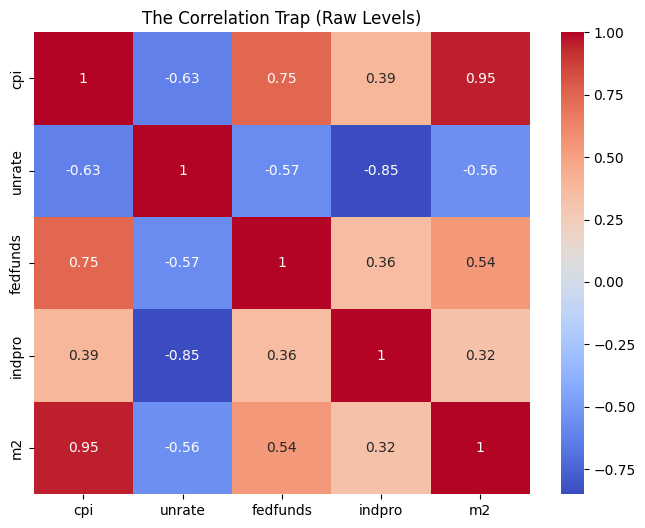

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("The Correlation Trap (Raw Levels)")
plt.show()

In [ ]:
# Define predictors (X). We leave out CPI as it is our theoretical target.
X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X) # Statsmodels requires a constant for VIF

# Calculate VIF iteratively
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_data)

,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


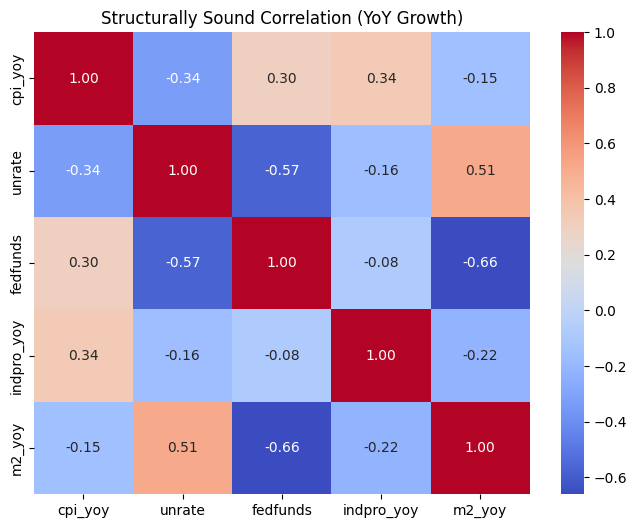

In [ ]:
df_t = df.copy()

# Transform trending variables to YoY growth (%)
for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

# Drop missing values created by the 12-month shift
df_t = df_t.dropna()

# Visualize the corrected correlations
cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ── 1. SIMULATED DATA ────────────────────────────────────────────────────────
# Replace this block with your real FRED DataFrame.
# Expected columns (levels): CPI, Unemployment, FedFunds, IndProd, M2
# Expected columns (YoY %): CPI_yoy, Unemployment_yoy, FedFunds_yoy,
#                            IndProd_yoy, M2_yoy
np.random.seed(42)
n = 300
t = np.arange(n)

raw = pd.DataFrame({
    "CPI":          100 + 0.08 * t + np.random.randn(n).cumsum() * 0.3,
    "Unemployment": 5   - 0.005 * t + np.random.randn(n).cumsum() * 0.1,
    "FedFunds":     3   + np.sin(t / 40) * 2 + np.random.randn(n) * 0.2,
    "IndProd":      100 + 0.06 * t + np.random.randn(n).cumsum() * 0.4,
    "M2":           8000 + 20 * t  + np.random.randn(n).cumsum() * 50,
})

# YoY transformation: (x_t / x_{t-12} - 1) * 100  [assumes monthly data]
yoy = raw.pct_change(periods=12).dropna() * 100
yoy.columns = [c + "_yoy" for c in raw.columns]

# ── 2. CORRELATION MATRICES ──────────────────────────────────────────────────
labels = ["CPI", "Unemployment", "FedFunds", "IndProd", "M2"]

corr_raw = raw.corr().round(2)           # levels  → often spuriously high
corr_yoy = yoy.corr().round(2)           # YoY     → economically meaningful
corr_yoy.columns = labels                # strip "_yoy" suffix for clean labels
corr_yoy.index   = labels

# ── 3. HELPER: build annotation text matrix ──────────────────────────────────
def make_annotations(corr_df):
    """Return a 2-D list of correlation value strings for heatmap cells."""
    return [[str(corr_df.iloc[i, j]) for j in range(len(corr_df.columns))]
            for i in range(len(corr_df))]

z_raw  = corr_raw.values.tolist()
z_yoy  = corr_yoy.values.tolist()
ann_raw = make_annotations(corr_raw)
ann_yoy = make_annotations(corr_yoy)

# ── 4. BUILD THE FIGURE ──────────────────────────────────────────────────────
# We create ONE heatmap trace. The dropdown will swap its `z` and `text`
# via Plotly's built-in `restyle` mechanism (no Python round-trip needed).

fig = go.Figure()

fig.add_trace(go.Heatmap(
    z           = z_raw,                 # initial data: raw levels
    x           = labels,
    y           = labels,
    text        = ann_raw,               # annotation values shown in cells
    texttemplate= "%{text}",             # render text as-is
    colorscale  = "RdBu",               # red = negative, blue = positive
    zmid        = 0,                     # anchor the diverging scale at 0
    zmin        = -1,
    zmax        = 1,
    colorbar    = dict(title="ρ"),
    hovertemplate="<b>%{y} × %{x}</b><br>ρ = %{z:.2f}<extra></extra>",
))

# ── 5. DROPDOWN VIA updatemenus ───────────────────────────────────────────────
# Each button calls fig.update_traces() under the hood via one of two methods:
#   • "restyle"  – updates trace properties (data, colors, etc.)
#   • "relayout" – updates layout properties (title, axes, etc.)
#   • "update"   – does both simultaneously  ← used here
#
# The `args` list contains [trace_patch, layout_patch].
# Plotly's JS engine merges these patches into the live figure on click —
# no server call, pure client-side state mutation.

fig.update_layout(
    updatemenus=[dict(
        type       = "dropdown",
        direction  = "down",
        x          = 0.0,
        xanchor    = "left",
        y          = 1.18,
        showactive = True,
        buttons    = [
            dict(
                label  = "📊 Raw Levels",
                method = "update",                      # restyle + relayout
                args   = [
                    {"z": [z_raw], "text": [ann_raw]},  # trace patch
                    {"title.text": "Correlation Matrix — Raw Levels<br>"
                                   "<sup>Warning: may contain spurious "
                                   "correlations from shared trends</sup>"}
                ],
            ),
            dict(
                label  = "📈 YoY Growth Rates",
                method = "update",
                args   = [
                    {"z": [z_yoy], "text": [ann_yoy]},  # swap z & annotations
                    {"title.text": "Correlation Matrix — YoY Growth Rates<br>"
                                   "<sup>Trend-adjusted: correlations reflect "
                                   "cyclical co-movement</sup>"}
                ],
            ),
        ],
    )],
    title = dict(
        text = "Correlation Matrix — Raw Levels<br>"
               "<sup>Warning: may contain spurious correlations from "
               "shared trends</sup>",
        x    = 0.5,
    ),
    font        = dict(size=13),
    width       = 680,
    height      = 620,
    plot_bgcolor= "#f9f9f9",
    xaxis       = dict(side="bottom", tickangle=-30),
    yaxis       = dict(autorange="reversed"),
    margin      = dict(t=120, l=80, r=40, b=80),
)

fig.show()
# fig.write_html("corr_heatmap.html")   # ← uncomment to export